In [ ]:
#PROBLEM STATEMENT:
#Dream Housing Finance company deals in all home loans. They have a presence across all urban, semi-urban and rural areas.
#Customers first apply for a home loan after that company validates the customer’s eligibility for a loan. The company wants
# to automate the loan eligibility process (real-time) based on customer detail provided while filling out the online application form.
#@ These details are Gender, Marital Status, Education, Number of Dependents, Income, Loan Amount, Credit History, and others
# To automate this process, they have given a problem to identify the customer segments, that are eligible for loan amounts so that
#they can specifically target these customers.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
#classification algorithm
from sklearn.linear_model import LogisticRegression
#evaluation libraries
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,f1_score,recall_score,classification_report
#KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import BaggingClassifier,AdaBoostClassifier

In [ ]:
#csv -coma separated values
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/IIT Palakkad Advanced AI/train_loan.csv')


In [ ]:
#copy original data for preprocessing
df=data.copy()

In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Data analysis( data behaviour analysis)

Univariate analysis(single feature analysis)

In [ ]:
df.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [ ]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [ ]:
df['ApplicantIncome'].dtypes

dtype('int64')

In [ ]:
num_cols = [column for column in df.columns if df[column].dtypes != 'O']

In [ ]:
df[num_cols]

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,5849,0.0,NaN,360.0,1.0
1,4583,1508.0,128.0,360.0,1.0
2,3000,0.0,66.0,360.0,1.0
3,2583,2358.0,120.0,360.0,1.0
4,6000,0.0,141.0,360.0,1.0
...,...,...,...,...,...
609,2900,0.0,71.0,360.0,1.0
610,4106,0.0,40.0,180.0,1.0
611,8072,240.0,253.0,360.0,1.0
612,7583,0.0,187.0,360.0,1.0


In [ ]:
#num_cols

In [ ]:
df['Dependents'].value_counts()

,count
Dependents,
0,345
1,102
2,101
3+,51


In [ ]:
df['Dependents'].nunique()

4

In [ ]:
df['Dependents'].unique()

array(['0', '1', '2', '3+', nan], dtype=object)

In [ ]:
df['Dependents'].replace({'3+':3}, inplace=True)

/tmp/ipykernel_1610/679725573.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Dependents'].replace({'3+':3}, inplace=True)


In [ ]:
df.shape

(614, 13)

In [ ]:
df['Loan_Amount_Term'].value_counts()

,count
Loan_Amount_Term,
360.0,512
180.0,44
480.0,15
300.0,13
84.0,4
240.0,4
120.0,3
60.0,2
36.0,2


In [ ]:
# discrete
df['Loan_Amount_Term'].nunique()

10

#univariate analysis of continuous numerical columns


/tmp/ipykernel_1610/2349853404.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['ApplicantIncome'])


<Axes: xlabel='ApplicantIncome', ylabel='Density'>

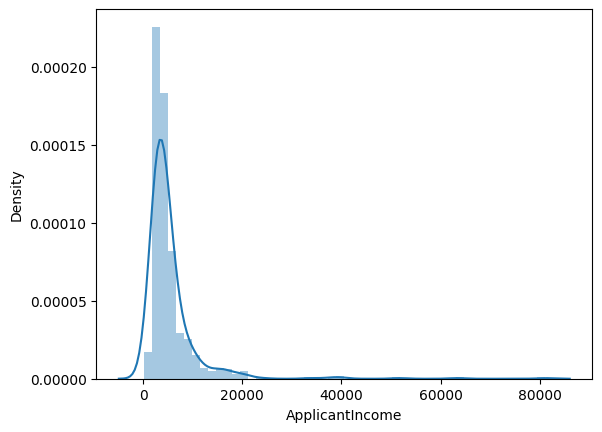

In [ ]:
sns.distplot(df['ApplicantIncome'])

<Axes: ylabel='ApplicantIncome'>

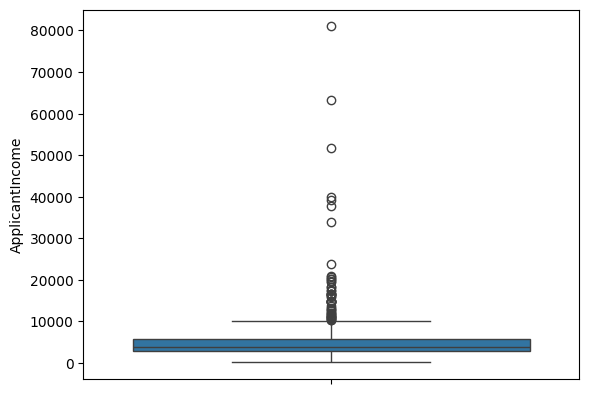

In [ ]:
sns.boxplot(df['ApplicantIncome'])

/tmp/ipykernel_1610/467202043.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['CoapplicantIncome'])


<Axes: xlabel='CoapplicantIncome', ylabel='Density'>

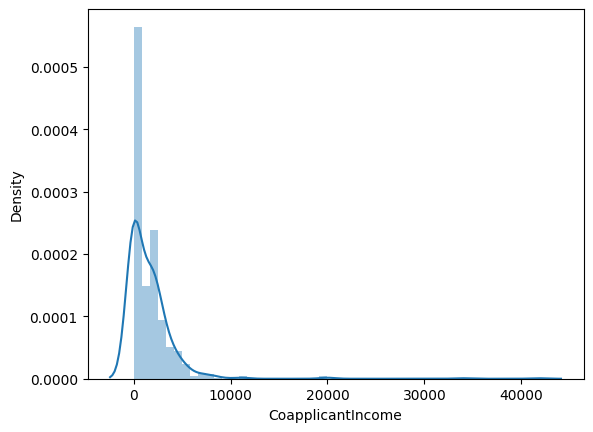

In [ ]:
#we have seen there is extreem outliers in paalicantIncome so not to suggest mean ,take median
sns.distplot(df['CoapplicantIncome'])

<Axes: ylabel='CoapplicantIncome'>

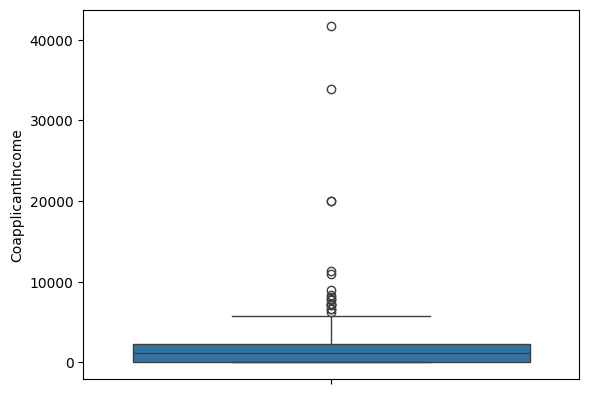

In [ ]:
sns.boxplot(df['CoapplicantIncome'])

<Axes: ylabel='LoanAmount'>

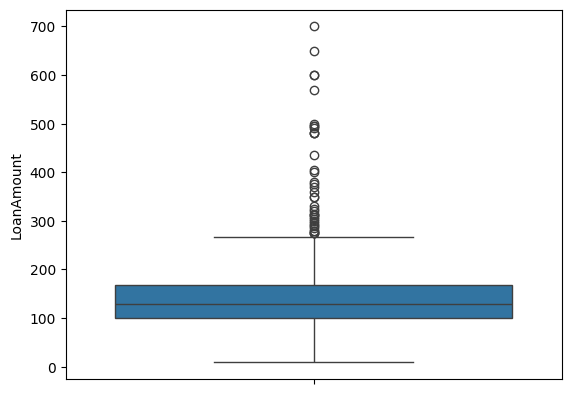

In [ ]:
sns.boxplot(df['LoanAmount'])

#Univariate analysis of Discrete Numerical Columns

Cardinality check of the columns

<Axes: xlabel='Dependents', ylabel='count'>

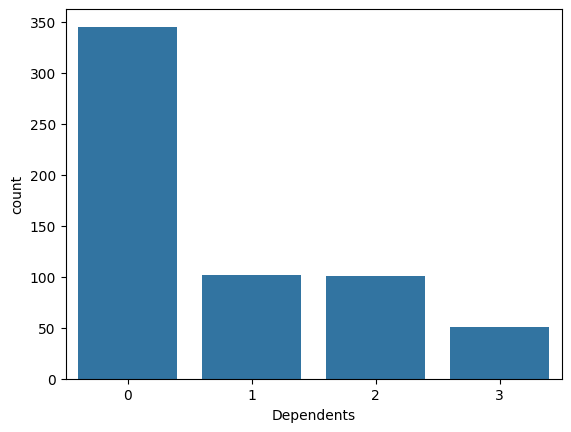

In [ ]:
sns.countplot(x='Dependents',data=df)

<Axes: xlabel='Loan_Amount_Term', ylabel='count'>

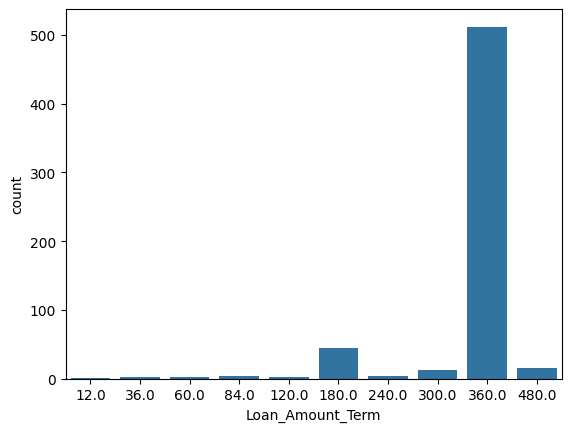

In [ ]:
sns.countplot(x='Loan_Amount_Term',data=df)

<Axes: xlabel='Credit_History', ylabel='count'>

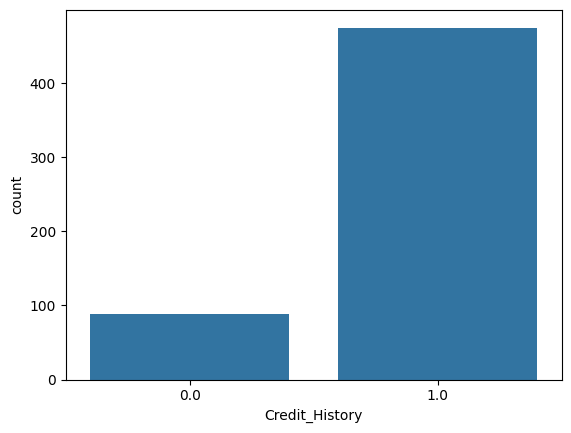

In [ ]:
sns.countplot(x='Credit_History',data=df)

Univariate analysis of categorical columns

In [ ]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

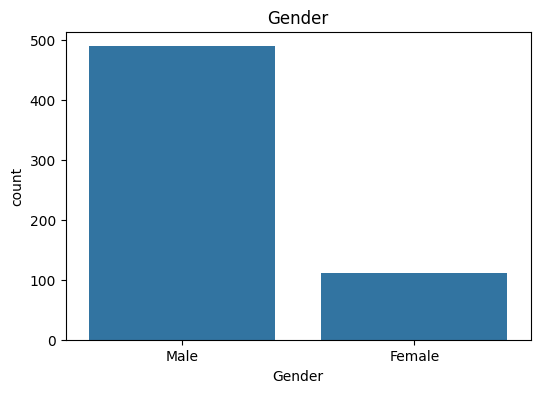

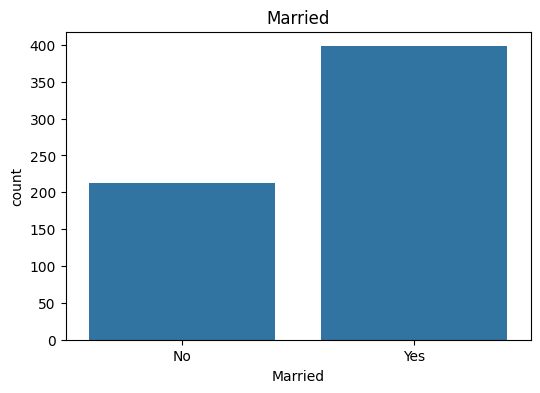

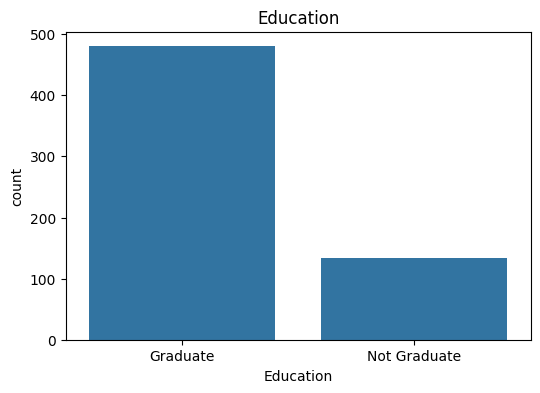

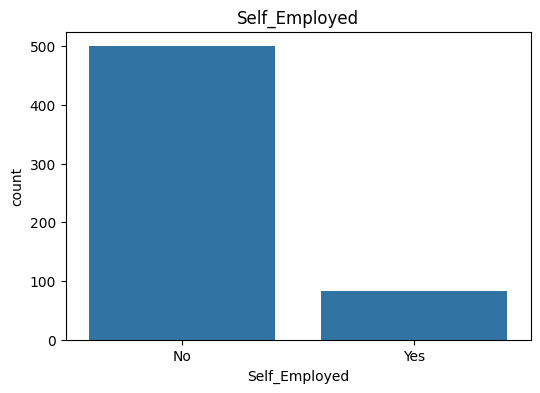

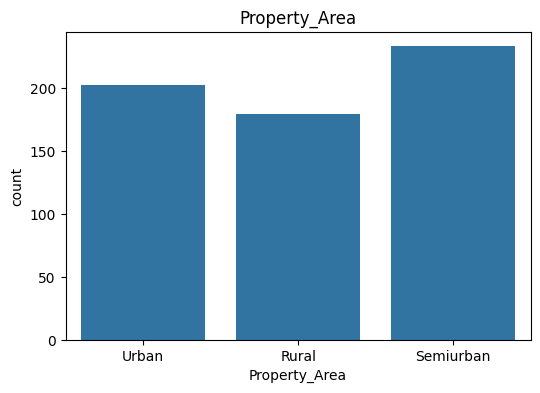

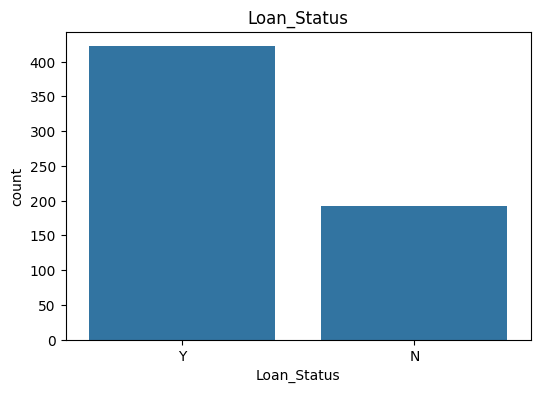

In [ ]:
cat_cols=['Gender','Married','Education','Self_Employed','Property_Area','Loan_Status']
for columns in cat_cols:
  plt.figure(figsize=(6,4))
  sns.countplot(x=columns, data=df)
  plt.title(columns)
  plt.show()

In [ ]:
percentage = df['Loan_Status'].value_counts(normalize=True) * 100
print(percentage)

Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64


#Bivariate analysis

<Axes: xlabel='Gender', ylabel='count'>

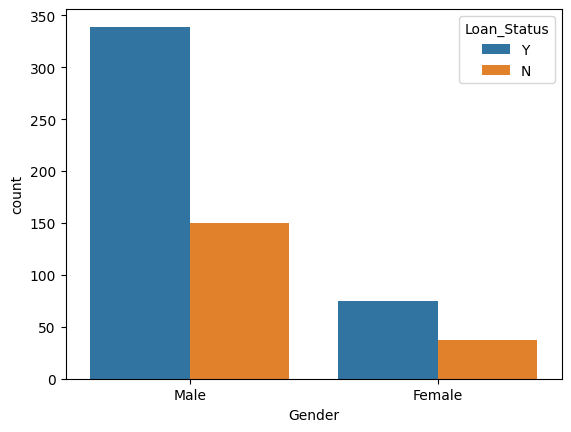

In [ ]:
sns.countplot(x='Gender',hue='Loan_Status',data=df)

<Axes: xlabel='Gender', ylabel='Percent'>

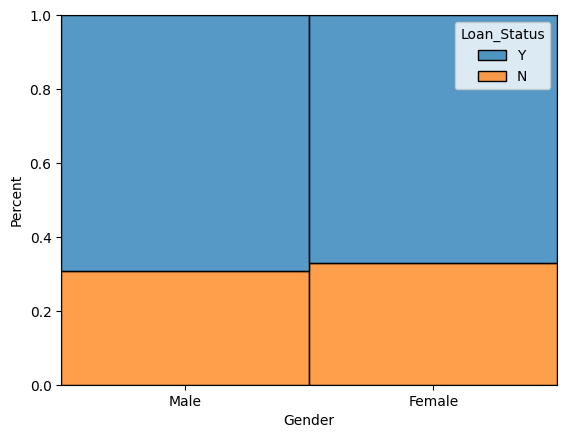

In [ ]:
sns.histplot(data=df,x='Gender',hue='Loan_Status',multiple='fill',stat='percent')

In [ ]:
pd.crosstab(df['Gender'],df['Loan_Status'],normalize='index')*100

Loan_Status,N,Y
Gender,,
Female,33.035714,66.964286
Male,30.674847,69.325153


In [ ]:
df['Gender'].value_counts()

,count
Gender,
Male,489
Female,112


<Axes: xlabel='Gender'>

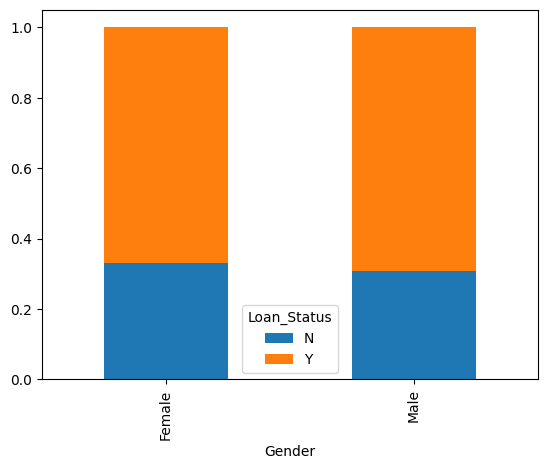

In [ ]:
pd.crosstab(df['Gender'],df['Loan_Status'],normalize='index').plot(kind='bar',stacked=True)

<Axes: xlabel='Married'>

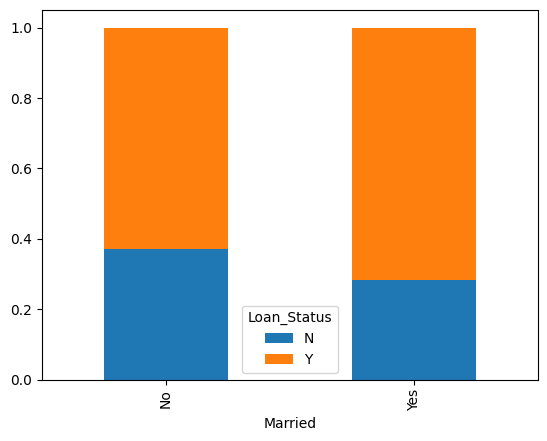

In [ ]:
pd.crosstab(df['Married'],df['Loan_Status'],normalize='index').plot(kind='bar',stacked=True)

In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.groupby('Married')['CoapplicantIncome'].mean()

,CoapplicantIncome
Married,
No,1316.558685
Yes,1794.632965


In [ ]:
df.groupby('Married')['ApplicantIncome'].mean()

,ApplicantIncome
Married,
No,4970.384977
Yes,5629.173367


<Axes: xlabel='Education'>

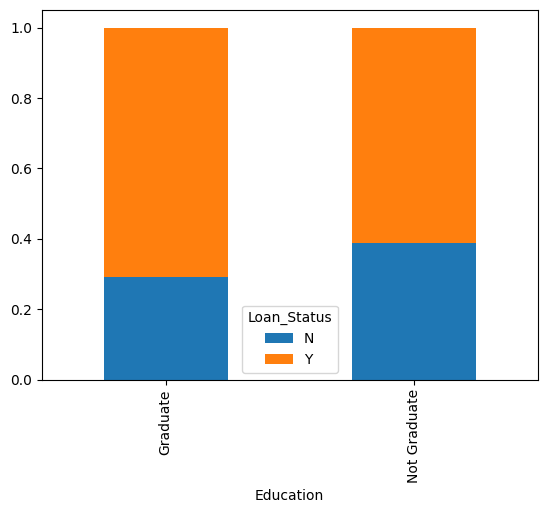

In [ ]:
pd.crosstab(df['Education'],df['Loan_Status'],normalize='index').plot(kind='bar',stacked=True)

In [ ]:
pd.crosstab(df['Education'],df['Loan_Status'],normalize='index')*100

Loan_Status,N,Y
Education,,
Graduate,29.166667,70.833333
Not Graduate,38.805970,61.194030


<Axes: xlabel='Self_Employed'>

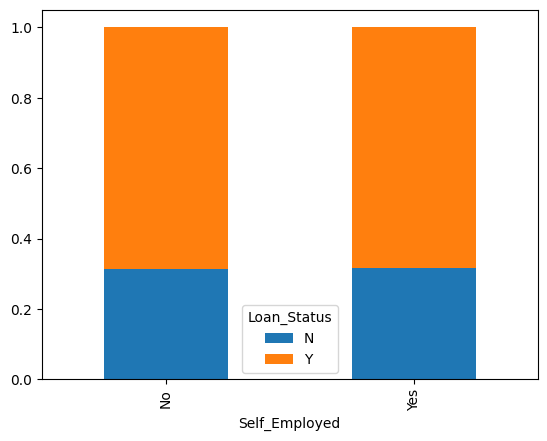

In [ ]:
#this column doesnot has any value
pd.crosstab(df['Self_Employed'],df['Loan_Status'],normalize='index').plot(kind='bar',stacked=True)

In [ ]:
pd.crosstab(df['Self_Employed'],df['Loan_Status'],normalize='index')*100

Loan_Status,N,Y
Self_Employed,,
No,31.400000,68.600000
Yes,31.707317,68.292683


#Multivariate analysis

<Axes: xlabel='Gender', ylabel='Count'>

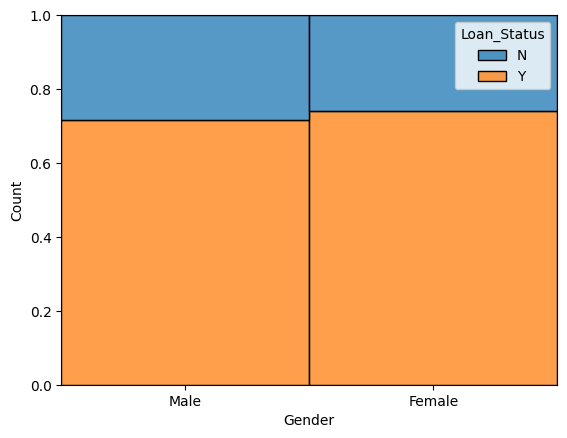

In [ ]:
sns.histplot(data=df[df['Married']=='Yes'], x='Gender',hue='Loan_Status', multiple='fill')

<Axes: xlabel='Gender', ylabel='Count'>

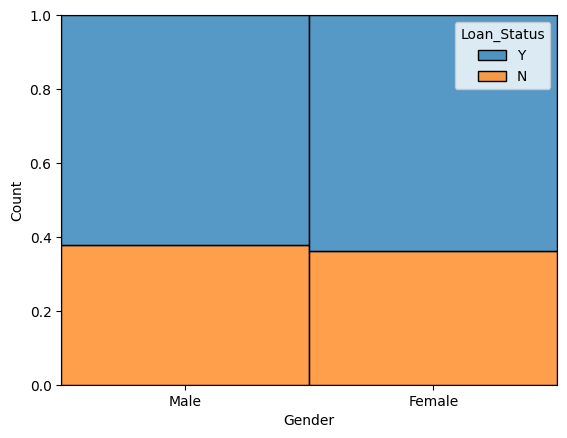

In [ ]:
sns.histplot(data=df[df['Married']=='No'], x='Gender',hue='Loan_Status', multiple='fill')

<Axes: xlabel='Education', ylabel='Count'>

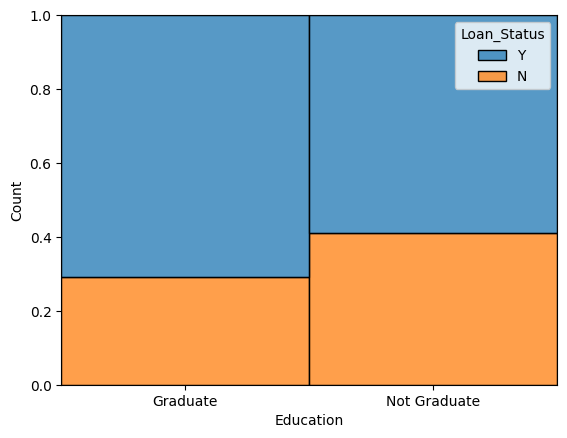

In [ ]:
sns.histplot(data=df[df['Self_Employed']=='Yes'], x='Education',hue='Loan_Status', multiple='fill')

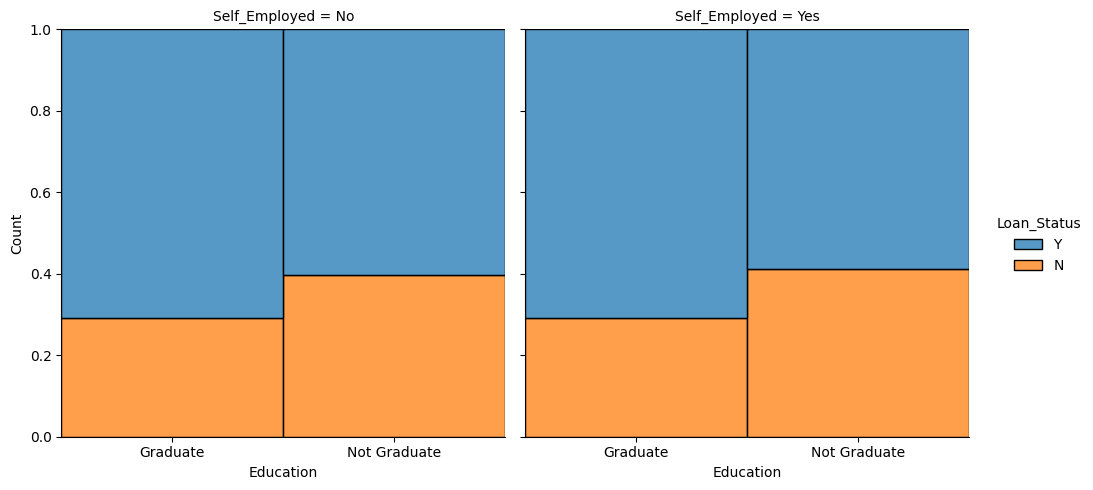

In [ ]:
sns.displot(data=df, x='Education',hue='Loan_Status',col='Self_Employed', multiple='fill')

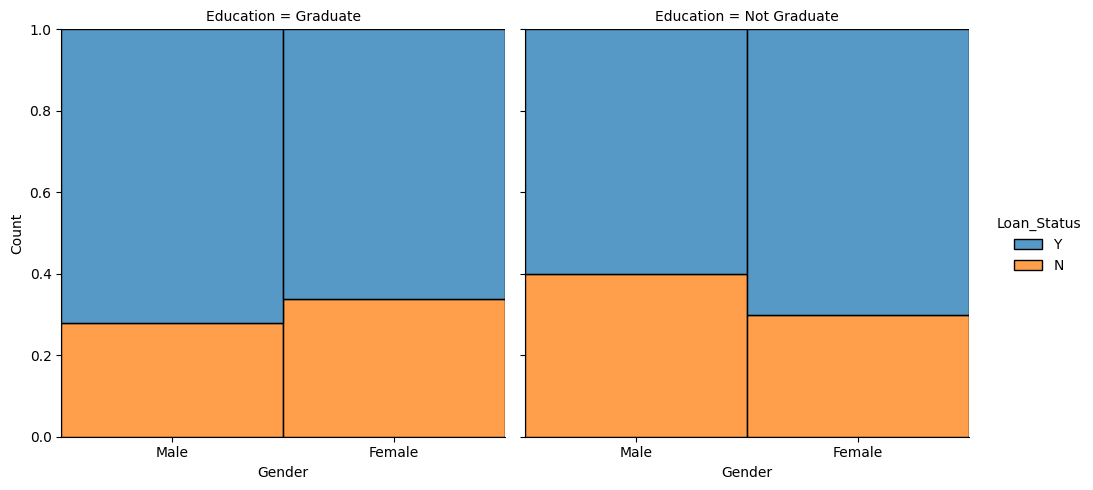

In [ ]:
sns.displot(data=df, x='Gender',hue='Loan_Status',col='Education', multiple='fill')

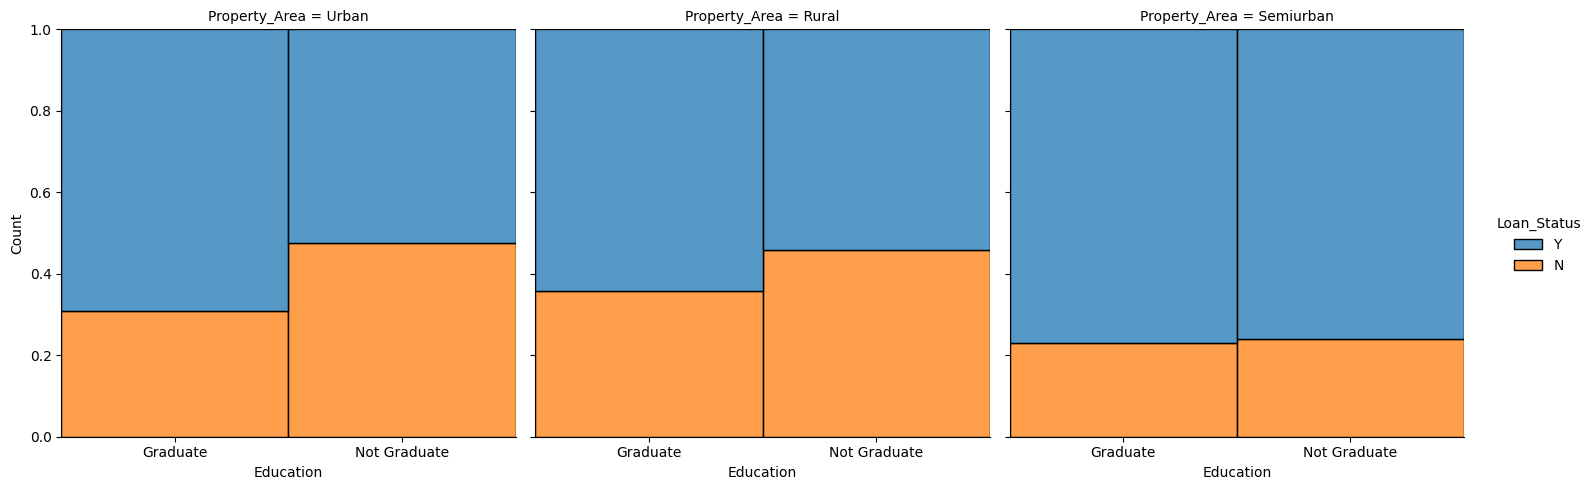

In [ ]:
sns.displot(data=df, x='Education',hue='Loan_Status',col='Property_Area', multiple='fill')

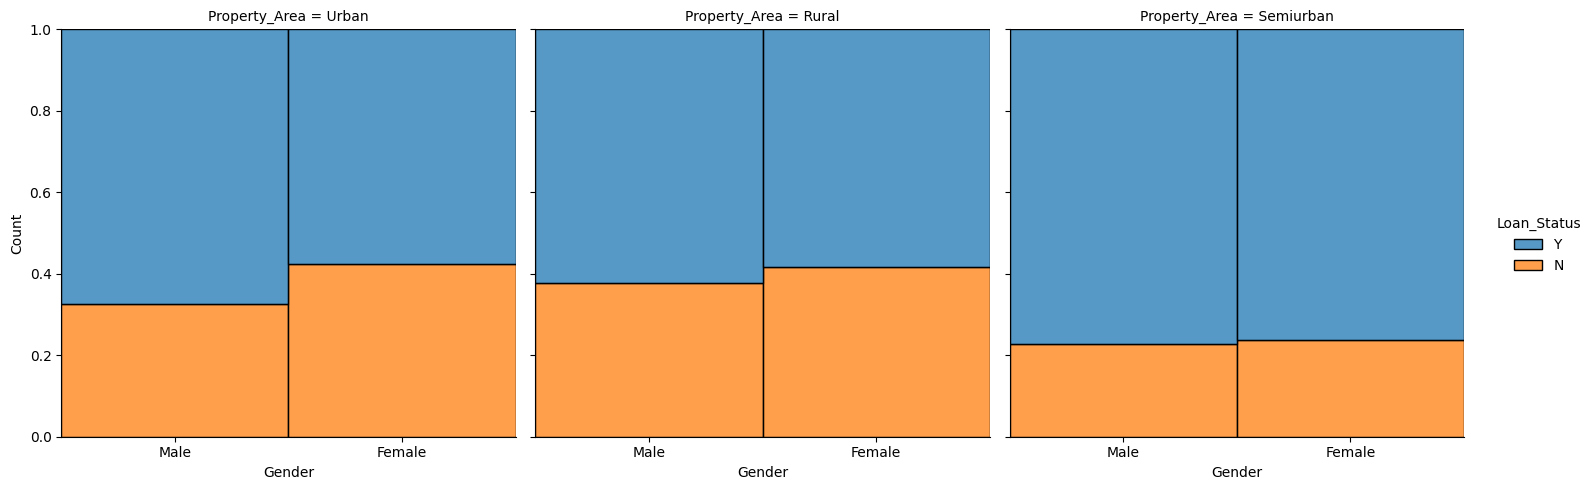

In [ ]:
sns.displot(data=df, x='Gender',hue='Loan_Status',col='Property_Area', multiple='fill')

From above all insights ,we can understand that if we are graduate or more qualified then getting loan approval is easy.

#Feature Engineering

In [ ]:
df.isna().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
df['Dependents'].unique()

array(['0', '1', '2', 3, nan], dtype=object)

In [ ]:
df['Dependents'].fillna(df['Dependents'].mode()[0],inplace=True)

In [ ]:
df.isna().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,0
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
df['Dependents']=df['Dependents'].astype('int')

In [ ]:
df[df['Gender'].isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
23,LP001050,NaN,Yes,2,Not Graduate,No,3365,1917.0,112.0,360.0,0.0,Rural,N
126,LP001448,NaN,Yes,3,Graduate,No,23803,0.0,370.0,360.0,1.0,Rural,Y
171,LP001585,NaN,Yes,3,Graduate,No,51763,0.0,700.0,300.0,1.0,Urban,Y
188,LP001644,NaN,Yes,0,Graduate,Yes,674,5296.0,168.0,360.0,1.0,Rural,Y
314,LP002024,NaN,Yes,0,Graduate,No,2473,1843.0,159.0,360.0,1.0,Rural,N
334,LP002103,NaN,Yes,1,Graduate,Yes,9833,1833.0,182.0,180.0,1.0,Urban,Y
460,LP002478,NaN,Yes,0,Graduate,Yes,2083,4083.0,160.0,360.0,NaN,Semiurban,Y
467,LP002501,NaN,Yes,0,Graduate,No,16692,0.0,110.0,360.0,1.0,Semiurban,Y
477,LP002530,NaN,Yes,2,Graduate,No,2873,1872.0,132.0,360.0,0.0,Semiurban,N
507,LP002625,NaN,No,0,Graduate,No,3583,0.0,96.0,360.0,1.0,Urban,N


In [ ]:
pd.crosstab(df['Dependents'],[df['Married'],df['Gender']],normalize='index')*100

Married            No                  Yes           
Gender         Female       Male    Female       Male
Dependents                                           
0           17.714286  31.714286  5.714286  44.857143
1           12.871287   9.900990  5.940594  71.287129
2            2.020202   6.060606  5.050505  86.868687
3            6.250000   6.250000  0.000000  87.500000

In [ ]:
mode_gender_3D_Y=df.loc[(df['Married']=="Yes")&(df['Dependents']==3),'Gender'].mode()[0]

In [ ]:
mode_gender_3D_Y

'Male'

In [ ]:
df.loc[(df['Gender'].isnull())&(df['Married']=='Yes')&(df['Dependents']==3),"Gender"] = mode_gender_3D_Y

In [ ]:
df[df['Gender'].isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
23,LP001050,NaN,Yes,2,Not Graduate,No,3365,1917.0,112.0,360.0,0.0,Rural,N
188,LP001644,NaN,Yes,0,Graduate,Yes,674,5296.0,168.0,360.0,1.0,Rural,Y
314,LP002024,NaN,Yes,0,Graduate,No,2473,1843.0,159.0,360.0,1.0,Rural,N
334,LP002103,NaN,Yes,1,Graduate,Yes,9833,1833.0,182.0,180.0,1.0,Urban,Y
460,LP002478,NaN,Yes,0,Graduate,Yes,2083,4083.0,160.0,360.0,NaN,Semiurban,Y
467,LP002501,NaN,Yes,0,Graduate,No,16692,0.0,110.0,360.0,1.0,Semiurban,Y
477,LP002530,NaN,Yes,2,Graduate,No,2873,1872.0,132.0,360.0,0.0,Semiurban,N
507,LP002625,NaN,No,0,Graduate,No,3583,0.0,96.0,360.0,1.0,Urban,N
576,LP002872,NaN,Yes,0,Graduate,No,3087,2210.0,136.0,360.0,0.0,Semiurban,N
588,LP002925,NaN,No,0,Graduate,No,4750,0.0,94.0,360.0,1.0,Semiurban,Y


In [ ]:
mode_gender_2D_Y = df.loc[(df['Married']=="Yes")&(df['Dependents']==2),"Gender"].mode()[0]
df.loc[(df['Gender'].isnull())&(df['Married']=='Yes')&(df['Dependents']==2),"Gender"] = mode_gender_2D_Y

mode_gender_1D_Y = df.loc[(df['Married']=="Yes")&(df['Dependents']==1),"Gender"].mode()[0]
df.loc[(df['Gender'].isnull())&(df['Married']=='Yes')&(df['Dependents']==1),"Gender"] = mode_gender_1D_Y

mode_gender_0D_Y = df.loc[(df['Married']=="Yes")&(df['Dependents']==0),"Gender"].mode()[0]
df.loc[(df['Gender'].isnull())&(df['Married']=='Yes')&(df['Dependents']==0),"Gender"] = mode_gender_0D_Y

In [ ]:
df.isna().sum()

,0
Loan_ID,0
Gender,3
Married,3
Dependents,0
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
df[df['Gender'].isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
507,LP002625,NaN,No,0,Graduate,No,3583,0.0,96.0,360.0,1.0,Urban,N
588,LP002925,NaN,No,0,Graduate,No,4750,0.0,94.0,360.0,1.0,Semiurban,Y
592,LP002933,NaN,No,3,Graduate,Yes,9357,0.0,292.0,360.0,1.0,Semiurban,Y


In [ ]:
mode_gender_3D_N = df.loc[(df['Married']=="No")&(df['Dependents']==3),"Gender"].mode()[0]
df.loc[(df['Gender'].isnull())&(df['Married']=='No')&(df['Dependents']==3),"Gender"] = mode_gender_3D_N

mode_gender_0D_N = df.loc[(df['Married']=="No")&(df['Dependents']==0),"Gender"].mode()[0]
df.loc[(df['Gender'].isnull())&(df['Married']=='No')&(df['Dependents']==0),"Gender"] = mode_gender_0D_N

In [ ]:
df.isna().sum()

,0
Loan_ID,0
Gender,0
Married,3
Dependents,0
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
df[df['Married'].isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
104,LP001357,Male,NaN,0,Graduate,No,3816,754.0,160.0,360.0,1.0,Urban,Y
228,LP001760,Male,NaN,0,Graduate,No,4758,0.0,158.0,480.0,1.0,Semiurban,Y
435,LP002393,Female,NaN,0,Graduate,No,10047,0.0,NaN,240.0,1.0,Semiurban,Y


In [ ]:
df.loc[104,'Married'] = 'Yes'
df.loc[228,'Married'] = 'No'
df.loc[435,'Married'] = 'No'

In [ ]:
df.isna().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
df[df['Self_Employed'].isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
11,LP001027,Male,Yes,2,Graduate,NaN,2500,1840.0,109.0,360.0,1.0,Urban,Y
19,LP001041,Male,Yes,0,Graduate,NaN,2600,3500.0,115.0,NaN,1.0,Urban,Y
24,LP001052,Male,Yes,1,Graduate,NaN,3717,2925.0,151.0,360.0,NaN,Semiurban,N
29,LP001087,Female,No,2,Graduate,NaN,3750,2083.0,120.0,360.0,1.0,Semiurban,Y
30,LP001091,Male,Yes,1,Graduate,NaN,4166,3369.0,201.0,360.0,NaN,Urban,N
95,LP001326,Male,No,0,Graduate,NaN,6782,0.0,NaN,360.0,NaN,Urban,N
107,LP001370,Male,No,0,Not Graduate,NaN,7333,0.0,120.0,360.0,1.0,Rural,N
111,LP001387,Female,Yes,0,Graduate,NaN,2929,2333.0,139.0,360.0,1.0,Semiurban,Y
114,LP001398,Male,No,0,Graduate,NaN,5050,0.0,118.0,360.0,1.0,Semiurban,Y
158,LP001546,Male,No,0,Graduate,NaN,2980,2083.0,120.0,360.0,1.0,Rural,Y


In [ ]:
high_income=df['ApplicantIncome'].median()
high_income

3812.5

In [ ]:
df.loc[(df['Self_Employed'].isnull())&(df['ApplicantIncome']>high_income),"Self_Employed"]="Yes"

In [ ]:
df['Self_Employed']=df['Self_Employed'].fillna('No')

In [ ]:
df.isna().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
df[df['LoanAmount'].isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
35,LP001106,Male,Yes,0,Graduate,No,2275,2067.0,NaN,360.0,1.0,Urban,Y
63,LP001213,Male,Yes,1,Graduate,No,4945,0.0,NaN,360.0,0.0,Rural,N
81,LP001266,Male,Yes,1,Graduate,Yes,2395,0.0,NaN,360.0,1.0,Semiurban,Y
95,LP001326,Male,No,0,Graduate,Yes,6782,0.0,NaN,360.0,NaN,Urban,N
102,LP001350,Male,Yes,0,Graduate,No,13650,0.0,NaN,360.0,1.0,Urban,Y
103,LP001356,Male,Yes,0,Graduate,No,4652,3583.0,NaN,360.0,1.0,Semiurban,Y
113,LP001392,Female,No,1,Graduate,Yes,7451,0.0,NaN,360.0,1.0,Semiurban,Y
127,LP001449,Male,No,0,Graduate,No,3865,1640.0,NaN,360.0,1.0,Rural,Y
202,LP001682,Male,Yes,3,Not Graduate,No,3992,0.0,NaN,180.0,1.0,Urban,N


In [ ]:
df['TotalIncome']=df['ApplicantIncome']+df['CoapplicantIncome']

In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,5849.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0


In [ ]:
df["IncomeBand"], income_bins = pd.qcut(df['TotalIncome'], 4, labels=False,retbins=True)

In [ ]:
print(income_bins)

[ 1442.    4166.    5416.5   7521.75 81000.  ]


In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,IncomeBand
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,5849.0,2
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,2
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,2


In [ ]:
df['LoanAmount']=df['LoanAmount'].fillna(df.groupby('IncomeBand')['LoanAmount'].transform('median'))

In [ ]:
df.isna().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,14


In [ ]:
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df.groupby("IncomeBand")["Loan_Amount_Term"].transform(lambda x:x.mode()[0]))

In [ ]:
df.isna().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,IncomeBand
0,LP001002,Male,No,0,Graduate,No,5849,0.0,141.0,360.0,1.0,Urban,Y,5849.0,2
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,2
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,2


In [ ]:
df['Credit_History'].unique()

array([ 1.,  0., nan])

In [ ]:
df['Credit_History']=df['Credit_History'].fillna(2)

In [ ]:
df['Credit_History'].unique()

array([1., 0., 2.])

In [ ]:
df.isna().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
df['LoanIncomeRatio'] = df['LoanAmount']/df['TotalIncome']

In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,IncomeBand,LoanIncomeRatio
0,LP001002,Male,No,0,Graduate,No,5849,0.0,141.0,360.0,1.0,Urban,Y,5849.0,2,0.024107
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,2,0.021015
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,0,0.022000
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,1,0.024287
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,2,0.023500


In [ ]:
df['HasCoapplicant'] = np.where(df['CoapplicantIncome'] > 0,1,0)

In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,IncomeBand,LoanIncomeRatio,HasCoapplicant
0,LP001002,Male,No,0,Graduate,No,5849,0.0,141.0,360.0,1.0,Urban,Y,5849.0,2,0.024107,0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,2,0.021015,1
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,0,0.022000,0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,1,0.024287,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,2,0.023500,0


/tmp/ipykernel_1610/2349853404.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['ApplicantIncome'])


<Axes: xlabel='ApplicantIncome', ylabel='Density'>

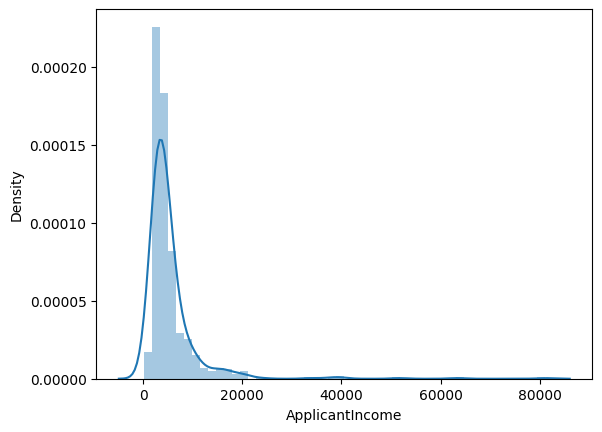

In [ ]:
sns.distplot(df['ApplicantIncome'])

In [ ]:
df['ApplicantIncome'] = np.log1p(df['ApplicantIncome'])

/tmp/ipykernel_1610/2349853404.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['ApplicantIncome'])


<Axes: xlabel='ApplicantIncome', ylabel='Density'>

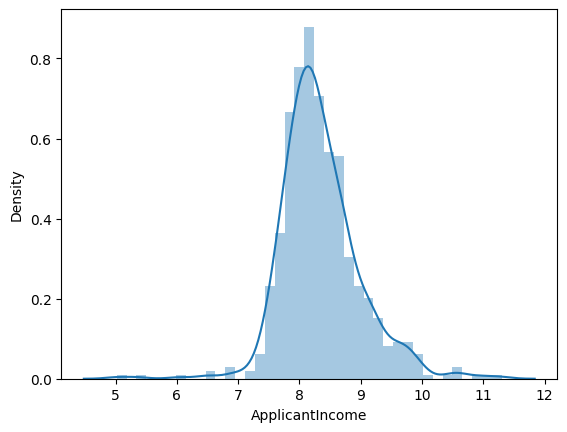

In [ ]:
sns.distplot(df['ApplicantIncome'])

/tmp/ipykernel_1610/2149142820.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['CoapplicantIncome'])


<Axes: xlabel='CoapplicantIncome', ylabel='Density'>

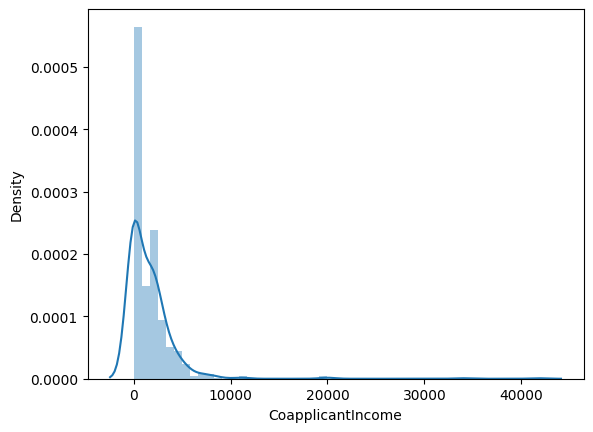

In [ ]:
sns.distplot(df['CoapplicantIncome'])

In [ ]:
df['CoapplicantIncome'] = np.log1p(df['CoapplicantIncome'])

/tmp/ipykernel_1610/2149142820.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['CoapplicantIncome'])


<Axes: xlabel='CoapplicantIncome', ylabel='Density'>

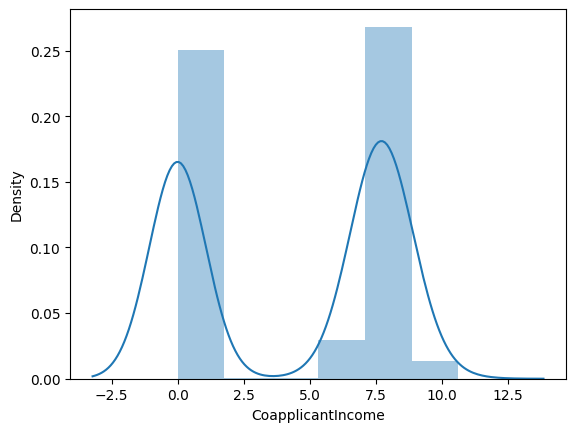

In [ ]:
sns.distplot(df['CoapplicantIncome'])

/tmp/ipykernel_1610/413488336.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['LoanAmount'])


<Axes: xlabel='LoanAmount', ylabel='Density'>

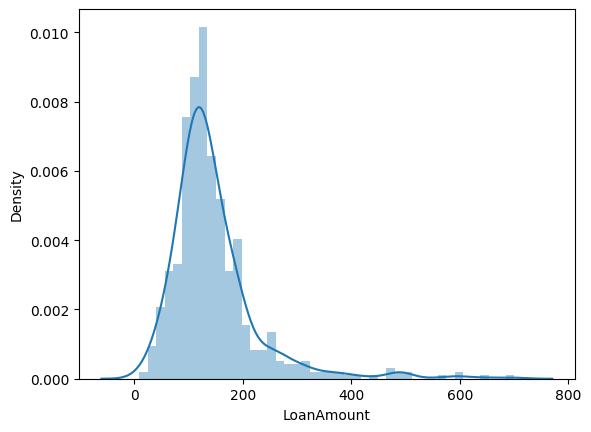

In [ ]:
sns.distplot(df['LoanAmount'])

In [ ]:
df['LoanAmount'] = np.log1p(df['LoanAmount'])

/tmp/ipykernel_1610/413488336.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['LoanAmount'])


<Axes: xlabel='LoanAmount', ylabel='Density'>

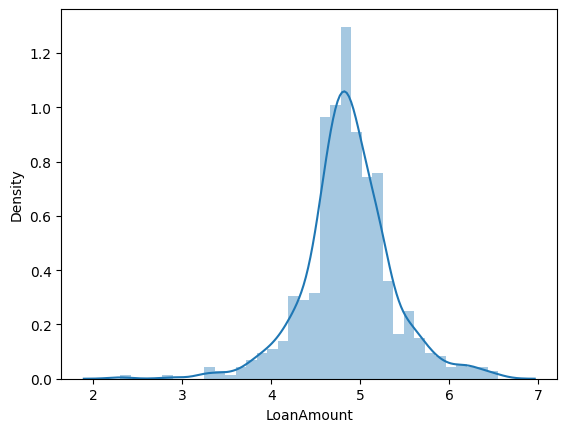

In [ ]:
sns.distplot(df['LoanAmount'])

In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,IncomeBand,LoanIncomeRatio,HasCoapplicant
0,LP001002,Male,No,0,Graduate,No,8.674197,0.000000,4.955827,360.0,1.0,Urban,Y,5849.0,2,0.024107,0
1,LP001003,Male,Yes,1,Graduate,No,8.430327,7.319202,4.859812,360.0,1.0,Rural,N,6091.0,2,0.021015,1
2,LP001005,Male,Yes,0,Graduate,Yes,8.006701,0.000000,4.204693,360.0,1.0,Urban,Y,3000.0,0,0.022000,0
3,LP001006,Male,Yes,0,Not Graduate,No,7.857094,7.765993,4.795791,360.0,1.0,Urban,Y,4941.0,1,0.024287,1
4,LP001008,Male,No,0,Graduate,No,8.699681,0.000000,4.955827,360.0,1.0,Urban,Y,6000.0,2,0.023500,0


In [ ]:
df.drop('Loan_ID',axis=1,inplace=True)

In [ ]:
df.dtypes

,0
Gender,object
Married,object
Dependents,int64
Education,object
Self_Employed,object
ApplicantIncome,float64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64
Credit_History,float64


In [ ]:
cat_cols = [column for column in df.columns if df[column].dtypes == 'O']

In [ ]:
cat_cols

['Gender',
 'Married',
 'Education',
 'Self_Employed',
 'Property_Area',
 'Loan_Status']

In [ ]:
target_col = "Loan_Status"
if target_col in cat_cols:
    cat_cols.remove(target_col)

In [ ]:
df[cat_cols]

,Gender,Married,Education,Self_Employed,Property_Area
0,Male,No,Graduate,No,Urban
1,Male,Yes,Graduate,No,Rural
2,Male,Yes,Graduate,Yes,Urban
3,Male,Yes,Not Graduate,No,Urban
4,Male,No,Graduate,No,Urban
...,...,...,...,...,...
609,Female,No,Graduate,No,Rural
610,Male,Yes,Graduate,No,Rural
611,Male,Yes,Graduate,No,Urban
612,Male,Yes,Graduate,No,Urban


In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
ohe = OneHotEncoder(drop="first", sparse_output=False)

In [ ]:
encoded_data = ohe.fit_transform(df[cat_cols])

In [ ]:
encoded_data

array([[1., 0., 0., 0., 0., 1.],
       [1., 1., 0., 0., 0., 0.],
       [1., 1., 0., 1., 0., 1.],
       ...,
       [1., 1., 0., 0., 0., 1.],
       [1., 1., 0., 0., 0., 1.],
       [0., 0., 0., 1., 1., 0.]])

In [ ]:
encoded_df = pd.DataFrame(encoded_data,columns = ohe.get_feature_names_out(cat_cols), index=df.index)

In [ ]:
encoded_df

,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,1.0,0.0,0.0,0.0,0.0,1.0
1,1.0,1.0,0.0,0.0,0.0,0.0
2,1.0,1.0,0.0,1.0,0.0,1.0
3,1.0,1.0,1.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...
609,0.0,0.0,0.0,0.0,0.0,0.0
610,1.0,1.0,0.0,0.0,0.0,0.0
611,1.0,1.0,0.0,0.0,0.0,1.0
612,1.0,1.0,0.0,0.0,0.0,1.0


In [ ]:
df.head(1)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,IncomeBand,LoanIncomeRatio,HasCoapplicant
0,Male,No,0,Graduate,No,8.674197,0.0,4.955827,360.0,1.0,Urban,Y,5849.0,2,0.024107,0


In [ ]:
df = pd.concat([df,encoded_df],axis=1)

In [ ]:
df.drop(columns=cat_cols,axis=1,inplace=True)

In [ ]:
df.head(10)

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,IncomeBand,LoanIncomeRatio,HasCoapplicant,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,8.674197,0.000000,4.955827,360.0,1.0,Y,5849.0,2,0.024107,0,1.0,0.0,0.0,0.0,0.0,1.0
1,1,8.430327,7.319202,4.859812,360.0,1.0,N,6091.0,2,0.021015,1,1.0,1.0,0.0,0.0,0.0,0.0
2,0,8.006701,0.000000,4.204693,360.0,1.0,Y,3000.0,0,0.022000,0,1.0,1.0,0.0,1.0,0.0,1.0
3,0,7.857094,7.765993,4.795791,360.0,1.0,Y,4941.0,1,0.024287,1,1.0,1.0,1.0,0.0,0.0,1.0
4,0,8.699681,0.000000,4.955827,360.0,1.0,Y,6000.0,2,0.023500,0,1.0,0.0,0.0,0.0,0.0,1.0
5,2,8.597482,8.342125,5.590987,360.0,1.0,Y,9613.0,3,0.027775,1,1.0,1.0,0.0,1.0,0.0,1.0
6,0,7.755339,7.324490,4.564348,360.0,1.0,Y,3849.0,0,0.024682,1,1.0,1.0,1.0,0.0,0.0,1.0
7,3,8.018625,7.826044,5.068904,360.0,0.0,N,5540.0,2,0.028520,1,1.0,1.0,0.0,0.0,1.0,0.0
8,2,8.295798,7.331060,5.129899,360.0,1.0,Y,5532.0,2,0.030369,1,1.0,1.0,0.0,0.0,0.0,1.0
9,1,9.460476,9.302828,5.857933,360.0,1.0,N,23809.0,3,0.014658,1,1.0,1.0,0.0,0.0,1.0,0.0


In [ ]:
#scaling- do all the columns into same range
# scaling only applicable to
from sklearn.preprocessing import StandardScaler

In [ ]:
scaling_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','TotalIncome','LoanIncomeRatio']

In [ ]:
scaler = StandardScaler()
df[scaling_cols]= scaler.fit_transform(df[scaling_cols])

In [ ]:
df.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,IncomeBand,LoanIncomeRatio,HasCoapplicant,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,0.516186,-1.107783,0.180177,0.273231,1.0,Y,-0.182184,2,0.034587,0,1.0,0.0,0.0,0.0,0.0,1.0
1,1,0.137806,0.782158,-0.014813,0.273231,1.0,N,-0.144684,2,-0.336243,1,1.0,1.0,0.0,0.0,0.0,0.0
2,0,-0.519479,-1.107783,-1.345255,0.273231,1.0,Y,-0.623656,0,-0.218066,0,1.0,1.0,0.0,1.0,0.0,1.0
3,0,-0.751605,0.897526,-0.144831,0.273231,1.0,Y,-0.322885,1,0.056162,1,1.0,1.0,1.0,0.0,0.0,1.0
4,0,0.555727,-1.107783,0.180177,0.273231,1.0,Y,-0.158785,2,-0.038172,0,1.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
X = df.drop("Loan_Status",axis=1)
y =df["Loan_Status"]

In [ ]:
X

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome,IncomeBand,LoanIncomeRatio,HasCoapplicant,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,0.516186,-1.107783,0.180177,0.273231,1.0,-0.182184,2,0.034587,0,1.0,0.0,0.0,0.0,0.0,1.0
1,1,0.137806,0.782158,-0.014813,0.273231,1.0,-0.144684,2,-0.336243,1,1.0,1.0,0.0,0.0,0.0,0.0
2,0,-0.519479,-1.107783,-1.345255,0.273231,1.0,-0.623656,0,-0.218066,0,1.0,1.0,0.0,1.0,0.0,1.0
3,0,-0.751605,0.897526,-0.144831,0.273231,1.0,-0.322885,1,0.056162,1,1.0,1.0,1.0,0.0,0.0,1.0
4,0,0.555727,-1.107783,0.180177,0.273231,1.0,-0.158785,2,-0.038172,0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,-0.572062,-1.107783,-1.199088,0.273231,1.0,-0.639152,0,0.079689,0,0.0,0.0,0.0,0.0,0.0,0.0
610,3,-0.032679,-1.107783,-2.342641,-2.522836,1.0,-0.452274,0,-1.688178,0,1.0,1.0,0.0,0.0,0.0,0.0
611,1,1.015921,0.308483,1.361123,0.273231,1.0,0.199475,3,0.793887,1,1.0,1.0,0.0,0.0,0.0,1.0
612,2,0.918972,-1.107783,0.750060,0.273231,1.0,0.086512,3,0.100996,0,1.0,1.0,0.0,0.0,0.0,1.0


In [ ]:
y

,Loan_Status
0,Y
1,N
2,Y
3,Y
4,Y
...,...
609,Y
610,Y
611,Y
612,Y


In [ ]:
#from sklearn.feature_selection import SelectKBest, mutual_info_classif
#selector = SelectKBest(mutual_info_classif,k=8)

In [ ]:
#X_new = selector.fit_transform(X,y)

In [ ]:
#X.columns[selector.get_support()]

In [ ]:
#split into train and test dataset
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state =42,stratify =y)

In [ ]:
X_train.columns

Index(['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'TotalIncome', 'IncomeBand',
       'LoanIncomeRatio', 'HasCoapplicant', 'Gender_Male', 'Married_Yes',
       'Education_Not Graduate', 'Self_Employed_Yes',
       'Property_Area_Semiurban', 'Property_Area_Urban'],
      dtype='object')

#Model selection

In [ ]:
rf =RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred= rf.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred)

0.8943089430894309

In [ ]:
confusion_matrix(y_test,y_pred)

array([[29,  9],
       [ 4, 81]])

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           N       0.88      0.76      0.82        38
           Y       0.90      0.95      0.93        85

    accuracy                           0.89       123
   macro avg       0.89      0.86      0.87       123
weighted avg       0.89      0.89      0.89       123



In [ ]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'n_estimators':[100,200,300,500],
    'max_depth': [None, 5,10,15,20],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'max_features':['sqrt','log2'],
    'bootstrap':[True,False]
}

In [ ]:
random_search = RandomizedSearchCV(
    estimator = RandomForestClassifier(random_state=42),
    param_distributions= param_dist,
    n_iter=30,
    scoring="accuracy",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=1
)

In [ ]:
random_search.fit(X_train,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.9s
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=30, n_jobs=1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 5, 10, 15, 20],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='accuracy', verbose=2)

In [ ]:
random_search.best_params_

{'n_estimators': 300,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_features': 'log2',
 'max_depth': 10,
 'bootstrap': True}

In [ ]:
random_search.best_score_

np.float64(0.7963512677798392)

In [ ]:
random_search.best_estimator_

RandomForestClassifier(max_depth=10, max_features='log2', min_samples_leaf=2,
                       min_samples_split=5, n_estimators=300, random_state=42)

In [ ]:
best_rf_model = random_search.best_estimator_

In [ ]:
y_pred_tuned = best_rf_model.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred_tuned)

0.8943089430894309

In [ ]:
import joblib

In [ ]:
joblib.dump(best_rf_model,'loan_rf_model.pkl')

['loan_rf_model.pkl']

In [ ]:
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

In [ ]:
joblib.dump(ohe,'onehot_encoder.pkl')

['onehot_encoder.pkl']

In [ ]:
joblib.dump(X.columns.tolist(),'model_columns.pkl')

['model_columns.pkl']

In [ ]:
joblib.dump(scaling_cols,'scaling_cols.pkl')

['scaling_cols.pkl']